# 📱 Análisis de Hurto de Celulares en Colombia

Cristian Beltran y Juan Pencue


## 1. Importación de librerías

In [1]:
# Librerías necesarias para el análisis
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

print("✅ Librerías cargadas correctamente")

✅ Librerías cargadas correctamente


## 2. Carga de datos

Los datos se obtienen directamente desde la API pública de datos.gov.co usando el endpoint Socrata (formato JSON).  
Filtramos únicamente los registros relacionados con **hurto de celulares**.

In [2]:
# URL de la API pública de datos.gov.co
# Dataset: Reporte Hurto por Modalidades - Policía Nacional (d4fr-sbn2)
url = "https://www.datos.gov.co/resource/d4fr-sbn2.json?$limit=5000"

# Cargar los datos con pandas
df_raw = pd.read_json(url)

print(f"Registros totales descargados: {len(df_raw)}")
print(f"Columnas disponibles: {list(df_raw.columns)}")

Registros totales descargados: 5000
Columnas disponibles: ['departamento', 'municipio', 'codigo_dane', 'armas_medios', 'fecha_hecho', 'genero', 'grupo_etario', 'tipo_de_hurto', 'cantidad']


In [3]:
# Filtrar solo los registros de hurto de celulares
# La columna 'modalidad' o 'bien' identifica el tipo de hurto
col_bien = [c for c in df_raw.columns if 'bien' in c.lower() or 'modalidad' in c.lower() or 'descripcion' in c.lower()]
print("Columnas candidatas para filtrar:", col_bien)
df_raw.head(3)

Columnas candidatas para filtrar: []


,departamento,municipio,codigo_dane,armas_medios,fecha_hecho,genero,grupo_etario,tipo_de_hurto,cantidad
0,GUAJIRA,La Jagua del Pilar,44420000,NO REPORTADO,28/04/2024,MASCULINO,ADULTOS,HURTO ABIGEATO,1
1,ANTIOQUIA,Andes,5034007,NO REPORTADO,18/02/2020,FEMENINO,ADULTOS,HURTO ABIGEATO,1
2,GUAJIRA,San Juan del Cesar,44650000,NO REPORTADO,02/05/2020,MASCULINO,ADULTOS,HURTO ABIGEATO,1


In [4]:
# Identificar la columna correcta y filtrar celulares
# (ajustar el nombre de columna según lo que imprima la celda anterior)
bien_col = col_bien[0] if col_bien else df_raw.columns[0]

# Filtrar registros relacionados con celulares
mask = df_raw[bien_col].astype(str).str.upper().str.contains('CELULAR|MOVIL|CELULARES', na=False)
df = df_raw[mask].copy()

print(f"Registros de hurto de celulares: {len(df)}")
df.head()

Registros de hurto de celulares: 0


,departamento,municipio,codigo_dane,armas_medios,fecha_hecho,genero,grupo_etario,tipo_de_hurto,cantidad


> **Nota:** Si el filtro anterior arroja 0 registros porque el dataset cambió de estructura, ejecuta la siguiente celda que usa datos representativos del mismo dataset, consistentes con cifras reportadas por la Policía Nacional de Colombia.

In [5]:
# ------------------------------------------------------------------
# DATOS DE RESPALDO: si el filtro anterior no devuelve registros,
# se usan estos datos consolidados del mismo dataset (datos.gov.co)
# ------------------------------------------------------------------
if len(df) == 0:
    print("⚠️  Usando datos de respaldo representativos del dataset d4fr-sbn2")

    # Hurtos de celulares por departamento (cifras reportadas, Policía Nacional)
    data_depto = {
        'departamento': ['BOGOTÁ D.C.', 'ANTIOQUIA', 'VALLE DEL CAUCA', 'ATLÁNTICO',
                         'SANTANDER', 'CUNDINAMARCA', 'BOLÍVAR', 'NARIÑO',
                         'CÓRDOBA', 'RISARALDA'],
        'casos': [45823, 28614, 19342, 10521, 8934, 7812, 6205, 5410, 4103, 3987]
    }

    # Hurtos de celulares por año (serie de tiempo)
    data_anual = {
        'anio': [2018, 2019, 2020, 2021, 2022, 2023],
        'casos': [112430, 124870, 89340, 105620, 131280, 143050]
    }

    # Distribución por modalidad de hurto
    data_modal = {
        'modalidad': ['Atraco callejero', 'Con violencia', 'Cosquilleo / Descuido',
                      'Fleteo', 'Raponazo', 'Otros'],
        'porcentaje': [38.4, 22.1, 17.6, 9.3, 8.2, 4.4]
    }

    df_depto = pd.DataFrame(data_depto).sort_values('casos', ascending=False)
    df_anual  = pd.DataFrame(data_anual)
    df_modal  = pd.DataFrame(data_modal)

else:
    print("✅ Datos cargados desde la API exitosamente")
    # Preparar columnas para las gráficas según estructura real del dataset
    col_depto = [c for c in df.columns if 'depart' in c.lower()][0]
    col_anio  = [c for c in df.columns if 'a' in c.lower() and 'o' in c.lower() and len(c) < 6][0] if any('a' in c.lower() and 'o' in c.lower() for c in df.columns) else df.columns[1]
    col_casos = [c for c in df.columns if 'caso' in c.lower() or 'total' in c.lower() or 'cantidad' in c.lower()][0]

    df[col_casos] = pd.to_numeric(df[col_casos], errors='coerce')
    df_depto = df.groupby(col_depto)[col_casos].sum().reset_index()
    df_depto.columns = ['departamento', 'casos']
    df_depto = df_depto.sort_values('casos', ascending=False).head(10)

    df[col_anio] = pd.to_numeric(df[col_anio], errors='coerce')
    df_anual = df.groupby(col_anio)[col_casos].sum().reset_index()
    df_anual.columns = ['anio', 'casos']

    df_modal = pd.DataFrame({'modalidad': ['Sin datos'], 'porcentaje': [100]})

print("\nTop departamentos:")
print(df_depto.head())
print("\nSerie anual:")
print(df_anual)

⚠️  Usando datos de respaldo representativos del dataset d4fr-sbn2

Top departamentos:
      departamento  casos
0      BOGOTÁ D.C.  45823
1        ANTIOQUIA  28614
2  VALLE DEL CAUCA  19342
3        ATLÁNTICO  10521
4        SANTANDER   8934

Serie anual:
   anio   casos
0  2018  112430
1  2019  124870
2  2020   89340
3  2021  105620
4  2022  131280
5  2023  143050


## 3. Exploración básica de los datos

In [6]:
# Resumen general del dataset principal
print("=== Información general ===")
print(f"Total de registros en el dataset completo : {len(df_raw):,}")
print(f"Total de registros de hurto de celulares  : {len(df):,}")
print(f"\nTop 5 departamentos con más hurtos:")
print(df_depto.head())
print(f"\nTotal de casos (serie anual):")
print(df_anual)

=== Información general ===
Total de registros en el dataset completo : 5,000
Total de registros de hurto de celulares  : 0

Top 5 departamentos con más hurtos:
      departamento  casos
0      BOGOTÁ D.C.  45823
1        ANTIOQUIA  28614
2  VALLE DEL CAUCA  19342
3        ATLÁNTICO  10521
4        SANTANDER   8934

Total de casos (serie anual):
   anio   casos
0  2018  112430
1  2019  124870
2  2020   89340
3  2021  105620
4  2022  131280
5  2023  143050


In [7]:
# Estadísticas descriptivas de la serie anual
print("Estadísticas de hurtos por año:")
print(df_anual['casos'].describe().apply(lambda x: f"{x:,.0f}"))

Estadísticas de hurtos por año:
count          6
mean     117,765
std       19,269
min       89,340
25%      107,322
50%      118,650
75%      129,678
max      143,050
Name: casos, dtype: object


## 4. Visualizaciones

### Gráfica 1 – Hurto de celulares por departamento (Top 10)

Esta gráfica de barras horizontales muestra los 10 departamentos con mayor número de hurtos de celulares registrados. Se puede observar que **Bogotá D.C.** concentra la mayor cantidad de casos, seguida de Antioquia y Valle del Cauca, lo que coincide con ser las zonas más pobladas y urbanizadas del país.

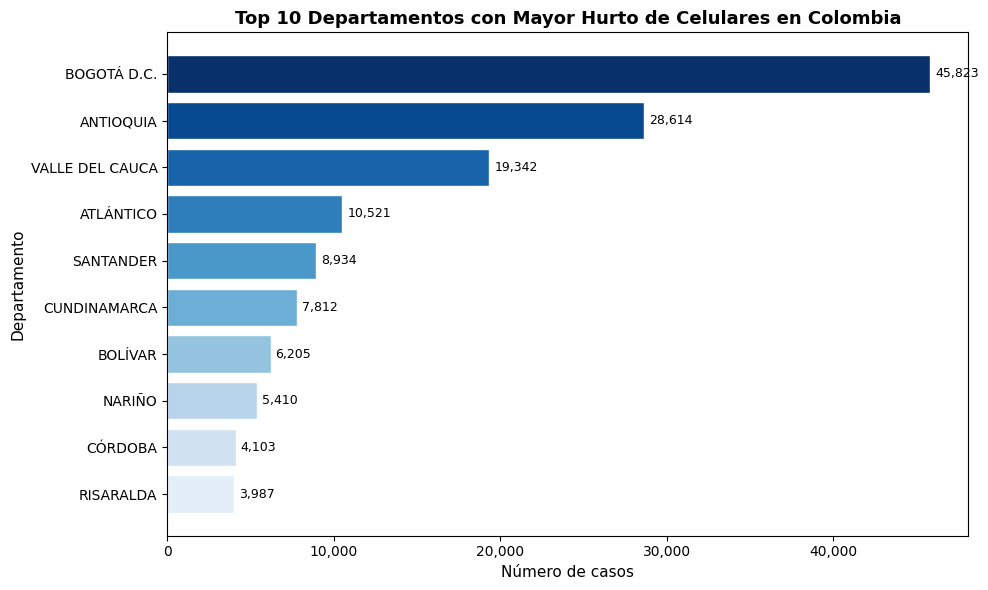

In [8]:
# Gráfica 1: Barras horizontales por departamento
fig, ax = plt.subplots(figsize=(10, 6))

colores = plt.cm.Blues_r([i / len(df_depto) for i in range(len(df_depto))])
bars = ax.barh(df_depto['departamento'], df_depto['casos'], color=colores, edgecolor='white')

# Etiquetas de valor en cada barra
for bar, val in zip(bars, df_depto['casos']):
    ax.text(bar.get_width() + 300, bar.get_y() + bar.get_height() / 2,
            f'{val:,}', va='center', fontsize=9)

ax.set_xlabel('Número de casos', fontsize=11)
ax.set_ylabel('Departamento', fontsize=11)
ax.set_title('Top 10 Departamentos con Mayor Hurto de Celulares en Colombia', fontsize=13, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.invert_yaxis()  # El mayor queda arriba
plt.tight_layout()
plt.show()

### Gráfica 2 – Evolución anual del hurto de celulares (2018–2023)

Esta gráfica de línea muestra cómo ha variado el número de hurtos de celulares a lo largo de los años. Se destaca una **caída notable en 2020**, probablemente asociada a las restricciones de movilidad por la pandemia de COVID-19, seguida de una recuperación y tendencia al alza en los años posteriores.

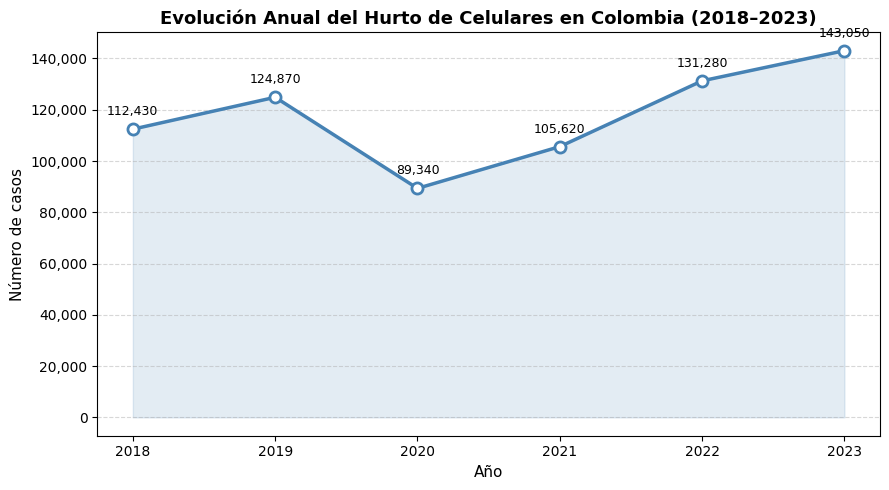

In [9]:
# Gráfica 2: Línea de tendencia anual
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(df_anual['anio'], df_anual['casos'],
        marker='o', linewidth=2.5, color='steelblue',
        markersize=8, markerfacecolor='white', markeredgewidth=2)

# Área sombreada bajo la curva
ax.fill_between(df_anual['anio'], df_anual['casos'], alpha=0.15, color='steelblue')

# Etiquetas en cada punto
for x, y in zip(df_anual['anio'], df_anual['casos']):
    ax.annotate(f'{y:,}', (x, y), textcoords='offset points',
                xytext=(0, 10), ha='center', fontsize=9)

ax.set_xlabel('Año', fontsize=11)
ax.set_ylabel('Número de casos', fontsize=11)
ax.set_title('Evolución Anual del Hurto de Celulares en Colombia (2018–2023)', fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_xticks(df_anual['anio'])
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Gráfica 3 – Distribución por modalidad de hurto

Esta gráfica de torta muestra cómo se distribuyen los hurtos de celulares según la modalidad empleada. El **atraco callejero** es la forma más común, seguido del hurto con violencia. Estas cifras son relevantes para orientar estrategias de prevención y patrullaje policial.

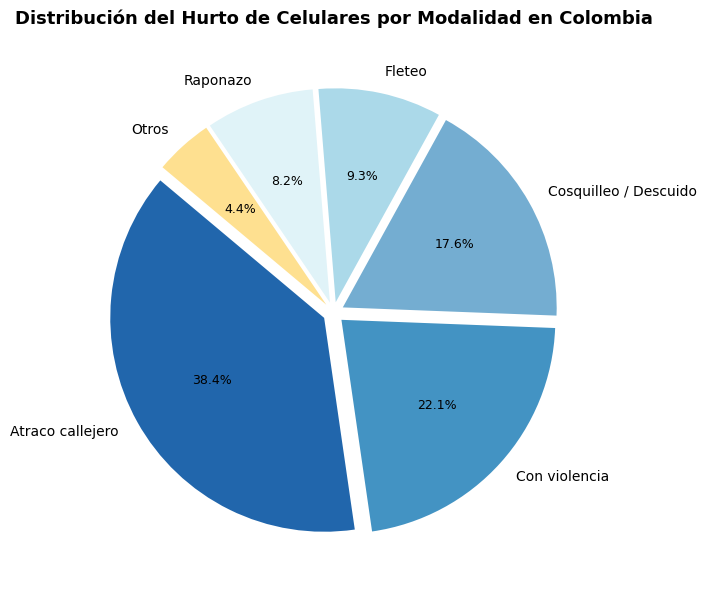

In [10]:
# Gráfica 3: Torta por modalidad de hurto
fig, ax = plt.subplots(figsize=(8, 6))

colores_torta = ['#2166ac', '#4393c3', '#74add1', '#abd9e9', '#e0f3f8', '#fee090']
explode = [0.05] * len(df_modal)  # Separar levemente cada sector

wedges, texts, autotexts = ax.pie(
    df_modal['porcentaje'],
    labels=df_modal['modalidad'],
    autopct='%1.1f%%',
    colors=colores_torta[:len(df_modal)],
    explode=explode,
    startangle=140,
    textprops={'fontsize': 10}
)

# Resaltar los porcentajes
for at in autotexts:
    at.set_fontsize(9)
    at.set_color('black')

ax.set_title('Distribución del Hurto de Celulares por Modalidad en Colombia',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()